## Neural networks and deep learning

Learn about neural nets and build a model for classifying images of clothes

### Fashion Classification

Dataset:

- Full: https://github.com/alexeygrigorev/clothing-dataset
- Small: https://github.com/alexeygrigorev/clothing-dataset-small

Links:

- https://cs231n.github.io

In [1]:
# clone the repo
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

fatal: destination path 'clothing-dataset-small' already exists and is not an empty directory.


## TensorFlow and Keras

- Installing TensorFlow
- Loading Images

In [1]:
# import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [2]:
path = "../06_Deep Learning/clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{path}/{name}"
img = load_img(full_name, target_size=(299, 299))

## Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [3]:
# use the pretrained model
model = Xception(weights="imagenet", input_shape=(299, 299, 3))


In [4]:
x = np.array([img])

# use the preprocess input function use by the creators to preprocess the img
X = preprocess_input(x)

# predict the class of the image
pred = model.predict(X)

# use decode predictions to see the class of the image
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


[[('n03595614', 'jersey', np.float32(0.679244)),
  ('n02916936', 'bulletproof_vest', np.float32(0.039600383)),
  ('n04370456', 'sweatshirt', np.float32(0.03529966)),
  ('n03710637', 'maillot', np.float32(0.010884161)),
  ('n04525038', 'velvet', np.float32(0.0018057661))]]

*The actual class of the image is a shirt, but shirt as a class is not seen in image net, so the pretrained model would be adjusted to be an ideal model for our task of classifying the image*

## Convolutional Neural Network

- Types of layers
- Convolutional Layers and filters
- Dense layers

There are more layers. Read here: https://cs231n.github.io/

## Transfer learning

- Reading data with ImageDataGenerator
- Train Xception on smaller images (150 x 150)

In [5]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150,150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [6]:
## check the classes in the train dataset
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [7]:
X, y = next(train_ds)

In [8]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [9]:
base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

# freeze convolutional layers
base_model.trainable=False

inputs = keras.Input(shape = (150, 150, 3))

base = base_model(inputs, training = False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [10]:
learning_rate = 0.01

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [11]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6721 - loss: 1.2590 - val_accuracy: 0.7595 - val_loss: 0.7754
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8282 - loss: 0.5331 - val_accuracy: 0.8240 - val_loss: 0.8139
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8784 - loss: 0.3523 - val_accuracy: 0.8035 - val_loss: 0.7791
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9078 - loss: 0.2572 - val_accuracy: 0.7654 - val_loss: 1.0223
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9446 - loss: 0.1555 - val_accuracy: 0.7801 - val_loss: 0.9657
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9625 - loss: 0.1110 - val_accuracy: 0.8152 - val_loss: 0.9202
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.9775 - loss: 0.0721 - val_accuracy: 0.8182 - val_loss: 0.8668
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9850 - loss: 0.0541 - val_accuracy: 0.8065 - v

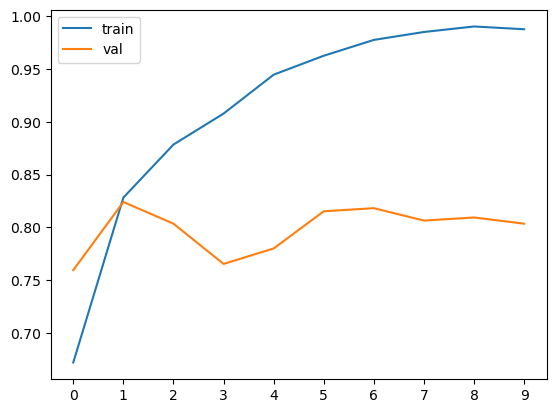

In [12]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Adjusting the learning rate

- What's the learning rate
- Trying different values

In [13]:
def make_model(learning_rate):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    outputs = keras.layers.Dense(10)(vectors)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [14]:
scores = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3553 - loss: 1.9259 - val_accuracy: 0.4985 - val_loss: 1.5738
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.5642 - loss: 1.3827 - val_accuracy: 0.6070 - val_loss: 1.2337
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.6340 - loss: 1.1383 - val_accuracy: 0.6686 - val_loss: 1.0613
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.6789 - loss: 0.9980 - val_accuracy: 0.6979 - val_loss: 0.9585
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7089 - loss: 0.9046 - val_accuracy: 0.7302 - val_loss: 0.8806
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7311 - loss: 0.8373 - val_accuracy: 0.7537 - val_loss: 0.8303
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7471 - loss: 0.7862 - val_accuracy: 0.7507 - val_loss: 0.7964
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7591 - loss: 0.7442 - val_accuracy: 0.7

*Plot the validation accuracy of the different learning rates*

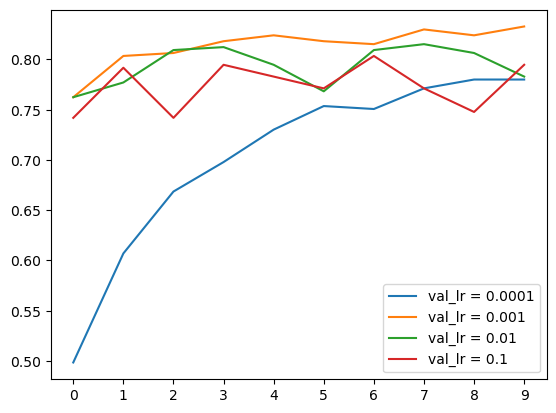

In [15]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*remove the learning rates with the worst performances*

In [16]:
del scores[0.0001]
del scores[0.1]

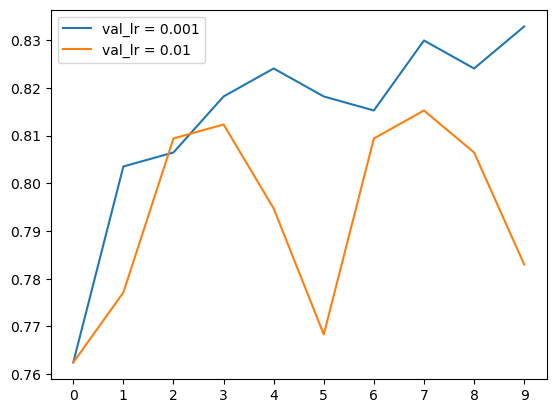

In [17]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*we will go with the learning rate of 0.001 since it is the best learning rate with the best validation scores*

## Checkpointing

- Savings the best model only
- Training a model with callbacks

In [18]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [19]:
learning_rate = 0.001
model = make_model(learning_rate=lr)
history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=val_ds, 
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.6656 - loss: 1.2457 - val_accuracy: 0.7361 - val_loss: 0.8775
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8175 - loss: 0.5769 - val_accuracy: 0.7801 - val_loss: 0.9983
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8719 - loss: 0.3670 - val_accuracy: 0.7419 - val_loss: 1.0913
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9182 - loss: 0.2281 - val_accuracy: 0.8123 - val_loss: 0.8046
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9384 - loss: 0.1682 - val_accuracy: 0.7771 - val_loss: 0.9960
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9472 - loss: 0.1522 - val_accuracy: 0.7947 - val_loss: 0.8833
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.9687 - loss: 0.0876 - val_accuracy: 0.8211 - val_loss: 0.8881
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.9736 - loss: 0.0833 - val_accuracy: 0.8065 - v

## Adding more layers

- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [20]:
def make_model(learning_rate, size_inner=100):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [21]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.5173 - loss: 1.3708 - val_accuracy: 0.6950 - val_loss: 0.8885
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.7327 - loss: 0.7775 - val_accuracy: 0.7918 - val_loss: 0.7187
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.7973 - loss: 0.5991 - val_accuracy: 0.7830 - val_loss: 0.6889
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.8383 - loss: 0.4922 - val_accuracy: 0.8065 - val_loss: 0.6593
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8673 - loss: 0.4239 - val_accuracy: 0.7918 - val_loss: 0.6440
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8921 - loss: 0.3687 - val_accuracy: 0.7713 - val_loss: 0.6538
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9032 - loss: 0.3228 - val_accuracy: 0.7889 - val_loss: 0.6405
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9254 - loss: 0.2766 - val_accuracy: 0.8182 

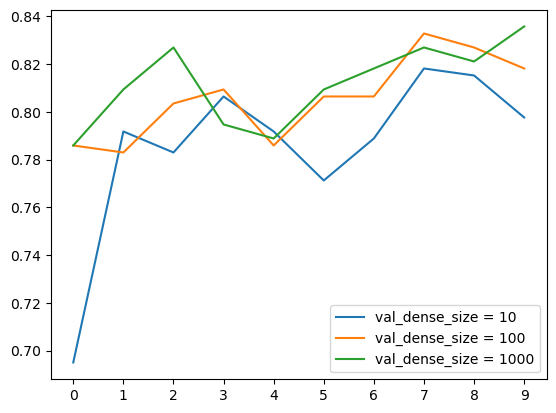

In [22]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_dense_size = {size}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Regularization and dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [23]:
def make_model(learning_rate, size_inner=100, droprate=0.5):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [24]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(learning_rate=learning_rate, 
                       size_inner=size,
                       droprate=droprate)
    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6643 - loss: 0.9536 - val_accuracy: 0.7947 - val_loss: 0.6737
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8178 - loss: 0.4947 - val_accuracy: 0.8182 - val_loss: 0.5746
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8820 - loss: 0.3529 - val_accuracy: 0.8211 - val_loss: 0.5530
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9273 - loss: 0.2448 - val_accuracy: 0.8094 - val_loss: 0.5273
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9527 - loss: 0.1765 - val_accuracy: 0.8182 - val_loss: 0.5618
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9759 - loss: 0.1174 - val_accuracy: 0.8152 - val_loss: 0.6219
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9870 - loss: 0.0840 - val_accuracy: 0.8152 - val_loss: 0.5855
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9886 - loss: 0.0689 - val_accuracy: 0.8534

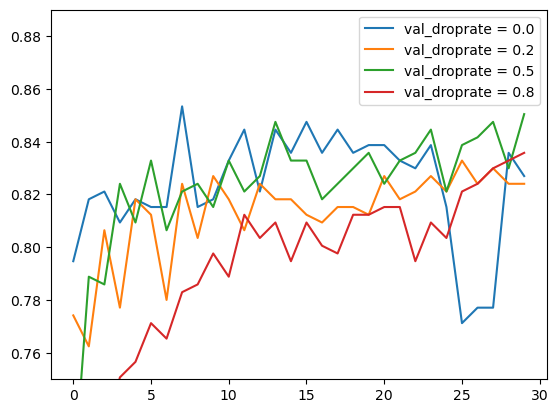

In [25]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_droprate = {size}')

plt.ylim(0.75,0.89)
plt.legend()
plt.show()

## Data Augumentation

- Different Data Augumentation
- Training a model with augumentation
- How to select data augumentation

for more info on the above visit: [ML Zoomcamp Youtube](https://www.youtube.com/watch?v=aoPfVsS3BDE&list=PL3MmuxUbc_hIhxl5Ji8t4O6lPAOpHaCLR&index=78)

In [26]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                               shear_range=10.0,
                               zoom_range=0.1,
                               vertical_flip=True)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150,150),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [27]:
learning_rate = 0.001
size = 100
dropout = 0.2

scores = {}


model = make_model(learning_rate=learning_rate, 
                    size_inner=size,
                    droprate=droprate)
history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.3598 - loss: 1.9975 - val_accuracy: 0.5748 - val_loss: 1.3035
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.4498 - loss: 1.6280 - val_accuracy: 0.6334 - val_loss: 1.0849
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.4905 - loss: 1.4816 - val_accuracy: 0.7126 - val_loss: 0.9440
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.5111 - loss: 1.4014 - val_accuracy: 0.7273 - val_loss: 0.9418
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5398 - loss: 1.3391 - val_accuracy: 0.7302 - val_loss: 0.9138
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.5372 - loss: 1.3343 - val_accuracy: 0.7507 - val_loss: 0.8804
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.5359 - loss: 1.3158 - val_accuracy: 0.7361 - val_loss: 0.8397
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.5544 - loss: 1.2404 - val_accuracy: 0.7419 - v

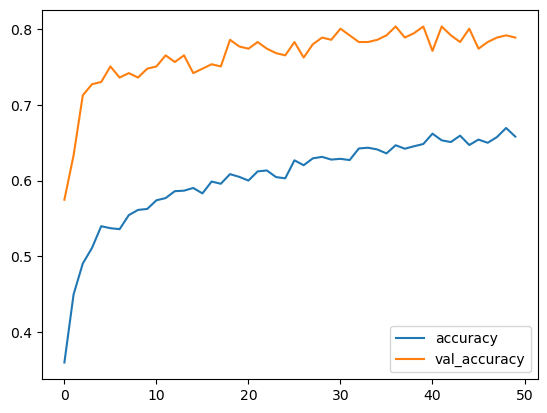

In [32]:
plt.plot(history.history['accuracy'], label = "accuracy")
plt.plot(history.history['val_accuracy'], label = "val_accuracy")
plt.legend()
plt.show()

Training a Larger Model
- Train a 299x299 model